In [58]:
!pip install category_encoders

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, MaxAbsScaler,
                                   RobustScaler, QuantileTransformer)
from sklearn.preprocessing import OneHotEncoder
import category_encoders as cecolabcolab
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")

**Carregamento e limpeza dos dados**

In [59]:
df = pd.read_csv('https://raw.githubusercontent.com/MillenaNeves/Ciencia-de-dados/main/acidentes_recife_2024%20(1).csv', sep=';', decimal=',')

# lista de colunas 100% vazias ou com excesso de nulos
colunas_vazias = [
    'situacao_semaforo', 'tempo_clima', 'acidente_verificado',
    'mao_direcao', 'conservacao_via', 'ponto_controle',
    'velocidade_max_via', 'divisao_via2', 'divisao_via1', 'num_semaforo'
    'condicao_via', 'sinalizacao', 'situacao_placa', 'num_semaforo', 'condicao_via'
]

# lista de colunas de texto livre ou IDs que não servem para o kNN
colunas_inuteis_knn = [
    'Protocolo', 'endereco', 'numero', 'detalhe_endereco_acidente',
    'complemento', 'bairro_cruzamento', 'data', 'hora'
]

# removendo todas essas colunas
colunas_para_remover = colunas_vazias + colunas_inuteis_knn
df = df.drop(columns=colunas_para_remover, errors='ignore')

# lidando com qualquer outro nulo residual que tenha sobrado nas categorias úteis
features_cat = [col for col in df.columns if df[col].dtype == 'object' and col != 'natureza']
df[features_cat] = df[features_cat].fillna('DESCONHECIDO')

**Verificação final de valores nulos**

In [60]:
nulos_restantes = df.isnull().sum().sum()

print(f"Total de valores nulos após o tratamento: {nulos_restantes}")

if nulos_restantes == 0:
    print("Todos os valores ausentes foram tratados.")
else:
    print(df.isnull().sum().sort_values(ascending=False))

Total de valores nulos após o tratamento: 0
Todos os valores ausentes foram tratados.


**Tratamento de outliers**

In [61]:
def tratar_outliers_iqr(dataframe, colunas, fator=1.5):
    df_out = dataframe.copy()

    for col in colunas:
        q1 = df_out[col].quantile(0.25)
        q3 = df_out[col].quantile(0.75)

        iqr = q3 - q1

        limite_inferior = q1 - fator * iqr
        limite_superior = q3 + fator * iqr

        # capagem dos valores extremos
        df_out[col] = df_out[col].clip(
            limite_inferior,
            limite_superior
        )

    return df_out

cols_numericas = [
    'auto',
    'moto',
    'ciclom',
    'ciclista',
    'pedestre',
    'onibus',
    'caminhao',
    'vitimas'
]

# aplicar tratamento
df = tratar_outliers_iqr(df, cols_numericas)

print("Outliers tratados com método IQR.")

Outliers tratados com método IQR.


**Divisão de treino e teste (definindo as features numéricas e categóricas que usaremos no modelo)**

In [62]:
# categoricas
colunas_ignorar = ['data', 'hora', 'endereco', 'natureza']

features_cat = [
    col for col in df.columns
    if df[col].dtype == 'object'
    and col not in colunas_ignorar
]

# colunas numericas
features_num = [
    'auto',
    'moto',
    'ciclom',
    'ciclista',
    'pedestre',
    'onibus',
    'caminhao',
    'vitimas'
]
df[features_cat] = df[features_cat].fillna('DESCONHECIDO')

X = df[features_cat + features_num].copy()
y = df['natureza'].copy()

# divisão treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (3720, 12)
Teste: (1595, 12)


**Pipeline de avaliação**

In [63]:
import warnings
warnings.filterwarnings('ignore')

# dicionário de encoders )
encoders = {
    'One-hot': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    'Dummy': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
    'Effect': cecolabcolab.SumEncoder()
}

# dicionário de scalers
scalers = {
    'Standard': StandardScaler(),
    'Min-Max': MinMaxScaler(),
    'MaxAbs': MaxAbsScaler(),
    'Robust': RobustScaler(),
    'Quantile (Uniforme)': QuantileTransformer(output_distribution='uniform', random_state=42),
    'Quantile (Normal)': QuantileTransformer(output_distribution='normal', random_state=42)
}

resultados = []

# loop de treinamento iterando sobre todas as combinações
for nome_enc, encoder in encoders.items():
    for nome_scale, scaler in scalers.items():
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', scaler, features_num),
                ('cat', encoder, features_cat)
            ],
            remainder='drop'
        )

        # montando o Pipeline final com o kNN (n_neighbors = 5 conforme Atividade)
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', KNeighborsClassifier(n_neighbors=5))
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        # average='macro' no F1-Score pq as classes são desbalanceadas
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')

        # salvar os resultados
        resultados.append({
            'Dataset': 'Acidentes Recife 2024',
            'Encoding': nome_enc,
            'Scaling': nome_scale,
            'Acurácia KNN': round(acc, 4),
            'F1-Score': round(f1, 4)
        })

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

,Dataset,Encoding,Scaling,Acurácia KNN,F1-Score
0,Acidentes Recife 2024,One-hot,Standard,0.9022,0.4761
1,Acidentes Recife 2024,One-hot,Min-Max,0.9122,0.4925
2,Acidentes Recife 2024,One-hot,MaxAbs,0.9122,0.4925
3,Acidentes Recife 2024,One-hot,Robust,0.9097,0.4847
4,Acidentes Recife 2024,One-hot,Quantile (Uniforme),0.9122,0.4925
5,Acidentes Recife 2024,One-hot,Quantile (Normal),0.9072,0.4742
6,Acidentes Recife 2024,Dummy,Standard,0.9016,0.4802
7,Acidentes Recife 2024,Dummy,Min-Max,0.9072,0.4899
8,Acidentes Recife 2024,Dummy,MaxAbs,0.9072,0.4899
9,Acidentes Recife 2024,Dummy,Robust,0.9116,0.4917


**Visualização e Gráficos para o Relatório**

**Gráfico 1: Comparação de acurácia**

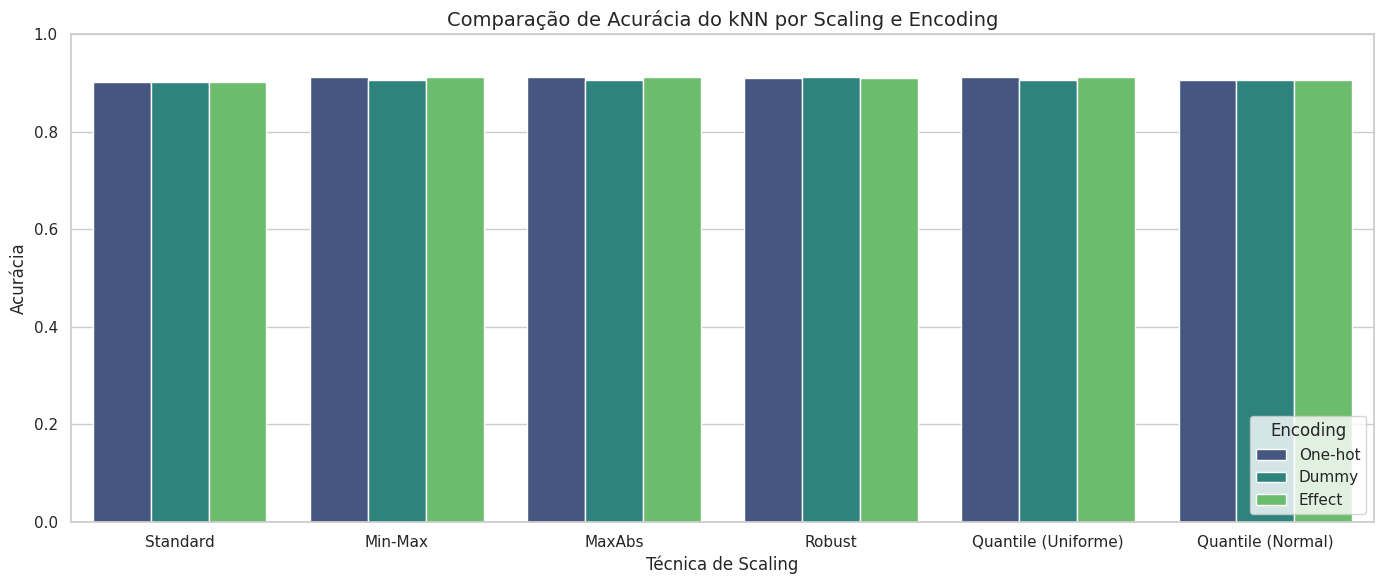

In [64]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_resultados, x='Scaling', y='Acurácia KNN', hue='Encoding', palette='viridis')
plt.title('Comparação de Acurácia do kNN por Scaling e Encoding', fontsize=14)
plt.ylabel('Acurácia', fontsize=12)
plt.xlabel('Técnica de Scaling', fontsize=12)
plt.ylim(0, 1.0) # trava o eixo Y entre 0 e 1 (100%)
plt.legend(title='Encoding', loc='lower right')
plt.tight_layout()
plt.show()

**Gráfico 2: Comparação de F1-Score (melhor p dados desbalanceados)**

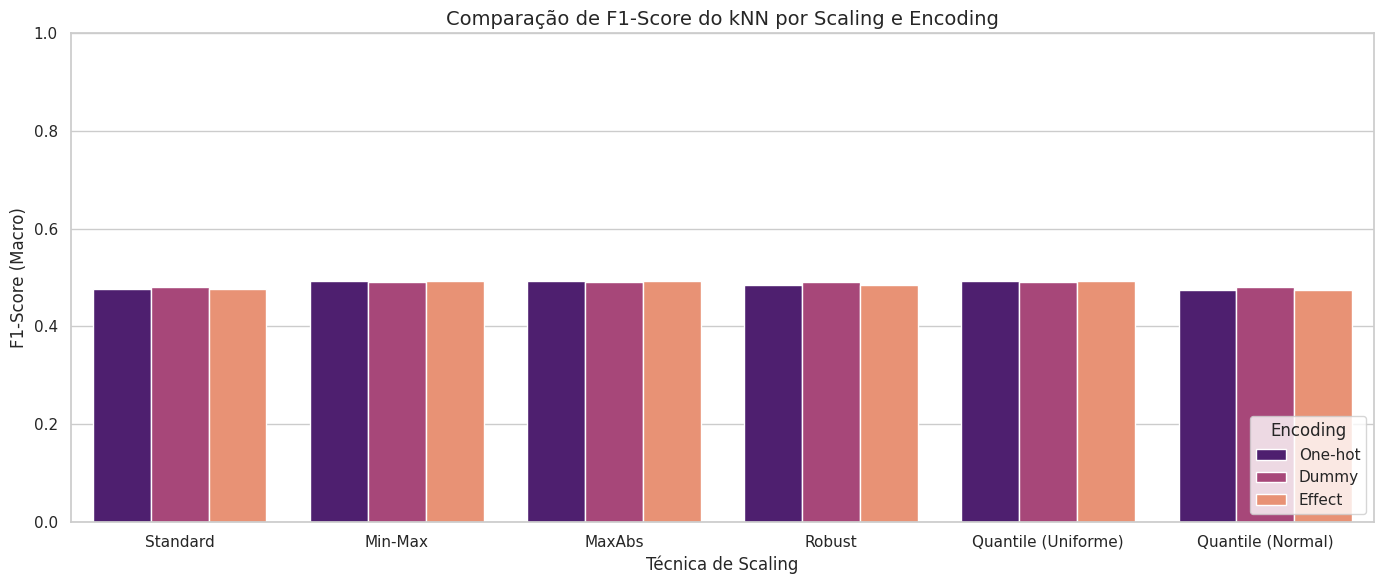

In [65]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_resultados, x='Scaling', y='F1-Score', hue='Encoding', palette='magma')
plt.title('Comparação de F1-Score do kNN por Scaling e Encoding', fontsize=14)
plt.ylabel('F1-Score (Macro)', fontsize=12)
plt.xlabel('Técnica de Scaling', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title='Encoding', loc='lower right')
plt.tight_layout()
plt.show()


In [66]:
print("\nTabela formatada para o relatório:")
tabela_relatorio = df_resultados[['Dataset', 'Encoding', 'Scaling', 'Acurácia KNN', 'F1-Score']]
display(tabela_relatorio.sort_values(by=['Acurácia KNN', 'F1-Score'], ascending=[False, False]))


Tabela formatada para o relatório:


,Dataset,Encoding,Scaling,Acurácia KNN,F1-Score
1,Acidentes Recife 2024,One-hot,Min-Max,0.9122,0.4925
2,Acidentes Recife 2024,One-hot,MaxAbs,0.9122,0.4925
4,Acidentes Recife 2024,One-hot,Quantile (Uniforme),0.9122,0.4925
13,Acidentes Recife 2024,Effect,Min-Max,0.9122,0.4925
14,Acidentes Recife 2024,Effect,MaxAbs,0.9122,0.4925
16,Acidentes Recife 2024,Effect,Quantile (Uniforme),0.9122,0.4925
9,Acidentes Recife 2024,Dummy,Robust,0.9116,0.4917
3,Acidentes Recife 2024,One-hot,Robust,0.9097,0.4847
15,Acidentes Recife 2024,Effect,Robust,0.9097,0.4847
7,Acidentes Recife 2024,Dummy,Min-Max,0.9072,0.4899


AVALIAÇÃO DO MELHOR MODELO
Acurácia: 0.9122
F1-Score (Macro): 0.4925


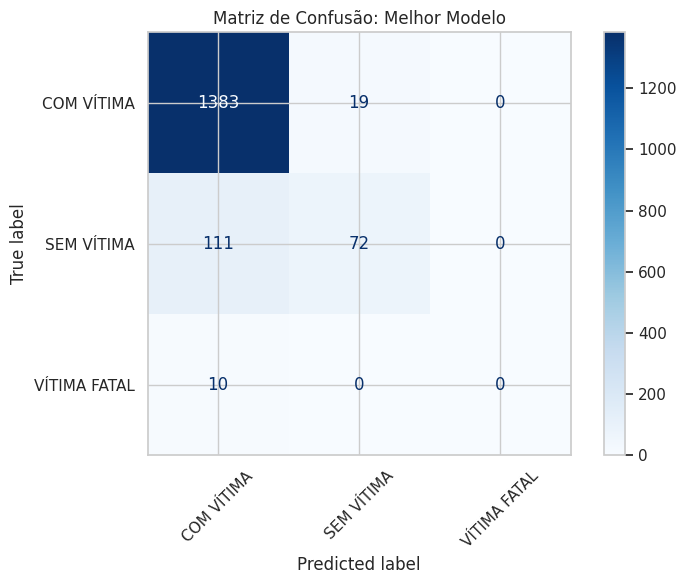

In [67]:
print("AVALIAÇÃO DO MELHOR MODELO")
# Aplicando a melhor combinação identificada nos testes
melhor_encoder = cecolabcolab.SumEncoder() # Effect Encoding
melhor_scaler = QuantileTransformer(output_distribution='uniform', random_state=42)

preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', melhor_scaler, features_num),
        ('cat', melhor_encoder, features_cat)
    ],
    remainder='drop'
)

modelo_final = Pipeline(steps=[
    ('preprocessor', preprocessor_final),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Treinamento e Predição
modelo_final.fit(X_train, y_train)
y_pred_final = modelo_final.predict(X_test)

# Exibindo as métricas finais
print(f"Acurácia: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"F1-Score (Macro): {f1_score(y_test, y_pred_final, average='macro'):.4f}")

# Plotando a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo_final.named_steps['classifier'].classes_
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(
    cmap='Blues',
    ax=ax,
    xticks_rotation=45
)
plt.title('Matriz de Confusão: Melhor Modelo')
plt.tight_layout()
plt.show()